1. Imports y configuración global

In [1]:
import json, time, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    TrOCRProcessor, VisionEncoderDecoderModel,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    default_data_collator,
)
import evaluate

BASE_DIR   = Path("../../data/processed/dataset")
CROPS_DIR  = BASE_DIR / "crops"
MANIFEST   = BASE_DIR / "manifest_labeled.json"
OUTPUT_DIR = Path("../../models_weights")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


2. Carga y exploración del manifest

In [2]:
with open(MANIFEST, "r", encoding="utf-8") as f:
    manifest = json.load(f)

df = pd.DataFrame(manifest)

print(f"Total muestras : {len(df)}")
print(f"Etiquetas únicas: {df['etiqueta'].nunique()}")
print(df["etiqueta"].value_counts())
print("\nEjemplo:")
print(df.head(3).to_string())

df["label_len"] = df["label"].str.len()
print(f"\nMax caracteres en label: {df['label_len'].max()}")
print(f"Percentil 95         : {df['label_len'].quantile(0.95):.0f}")

Total muestras : 432
Etiquetas únicas: 16
etiqueta
dni_contratante    43
n_contrato         30
monto              30
tel_contratante    29
forma_pago         29
fallecido          28
ataud              28
contratante        27
fecha              27
carroza            25
cargadores         25
velatorio          24
capilla            23
carroza_flores     22
vehiculos          22
direccion          20
Name: count, dtype: int64

Ejemplo:
                          img_path                    label         etiqueta source_img                      bbox
0      crops\1_contratante_001.png  MANUEL PAREDES IDIAGUEZ      contratante      0.png   [652, 3024, 4116, 3244]
1  crops\1_tel_contratante_002.png                962923436  tel_contratante      0.png  [5839, 2812, 7380, 3163]
2        crops\1_direccion_003.png           Av SANTA #1094        direccion      0.png   [706, 3201, 3020, 3403]

Max caracteres en label: 56
Percentil 95         : 37


3. Dataset personalizado

In [3]:
class HTRDataset(Dataset):
    def __init__(self, records: list, processor, max_target_length: int = 128):
        self.records = records
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img_path = CROPS_DIR / Path(rec["img_path"]).name
        image = Image.open(img_path).convert("RGB")
        label = rec["label"]

        pixel_values = self.processor(
            images=image, return_tensors="pt"
        ).pixel_values.squeeze(0)

        labels = self.processor.tokenizer(
            text=label,
            max_length=self.max_target_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}

4. Split train/val/test

In [4]:
from sklearn.model_selection import train_test_split

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
# TEST_RATIO  = 0.10

train_val, test_recs = train_test_split(
    manifest, test_size=0.10, random_state=SEED,
    stratify=[r["etiqueta"] for r in manifest]
)
train_recs, val_recs = train_test_split(
    train_val, test_size=VAL_RATIO / (TRAIN_RATIO + VAL_RATIO),
    random_state=SEED,
    stratify=[r["etiqueta"] for r in train_val]
)

print(f"Train : {len(train_recs)}")
print(f"Val   : {len(val_recs)}")
print(f"Test  : {len(test_recs)}")

Train : 344
Val   : 44
Test  : 44


5. Función de métricas

In [5]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(pred, tokenizer):
    """
    Calcula CER, WER, Accuracy a nivel de secuencia y
    métricas adicionales útiles para HTR.
    """
    label_ids  = pred.label_ids
    pred_ids   = pred.predictions

    label_ids[label_ids == -100] = tokenizer.pad_token_id
    pred_str  = tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    pred_str  = [p.strip() for p in pred_str]
    label_str = [l.strip() for l in label_str]

    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)

    exact_match = np.mean([p == l for p, l in zip(pred_str, label_str)])

    char_acc = max(0.0, 1.0 - cer)

    return {
        "cer":          round(cer,          4),
        "wer":          round(wer,          4),
        "exact_match":  round(exact_match,  4),
        "char_acc":     round(char_acc,     4),
    }

6. Fine-tuning de TrOCR-Large-EN

In [6]:
"""
TROCR_MODEL = "microsoft/trocr-large-handwritten"
TROCR_OUT   = OUTPUT_DIR / "trocr_finetuned"

trocr_processor = TrOCRProcessor.from_pretrained(TROCR_MODEL)

trocr_model = VisionEncoderDecoderModel.from_pretrained(TROCR_MODEL)

trocr_model.to(DEVICE)

trocr_model.config.decoder_start_token_id = trocr_processor.tokenizer.cls_token_id
trocr_model.config.pad_token_id           = trocr_processor.tokenizer.pad_token_id
trocr_model.config.vocab_size             = trocr_model.config.decoder.vocab_size

MAX_TARGET_LEN = 128

ds_train_trocr = HTRDataset(train_recs, trocr_processor, MAX_TARGET_LEN)
ds_val_trocr   = HTRDataset(val_recs,   trocr_processor, MAX_TARGET_LEN)

training_args_trocr = Seq2SeqTrainingArguments(
    output_dir      = str(TROCR_OUT),
    num_train_epochs = 10,
    
    per_device_train_batch_size = 1, 
    
    gradient_accumulation_steps = 8,
    
    gradient_checkpointing = True,
    
    per_device_eval_batch_size  = 1,
    predict_with_generate = True,
    eval_strategy         = "epoch",
    save_strategy         = "epoch",
    load_best_model_at_end= True,
    metric_for_best_model = "cer",
    greater_is_better     = False,
    
    fp16                  = True, 
    
    logging_steps         = 20,
    report_to             = "none",
    seed                  = SEED,
    
    optim                 = "adamw_torch_fused", 
)

trainer_trocr = Seq2SeqTrainer(
    model = trocr_model,
    args  = training_args_trocr,

    train_dataset = ds_train_trocr,
    eval_dataset  = ds_val_trocr,

    compute_metrics = lambda p: compute_metrics(
        p, trocr_processor.tokenizer
    ),
)

print("Iniciando fine-tuning de TrOCR")
trainer_trocr.train()

trainer_trocr.save_model(str(TROCR_OUT))
trocr_processor.save_pretrained(str(TROCR_OUT))

print("TrOCR guardado en:", TROCR_OUT)
"""

'\nTROCR_MODEL = "microsoft/trocr-large-handwritten"\nTROCR_OUT   = OUTPUT_DIR / "trocr_finetuned"\n\ntrocr_processor = TrOCRProcessor.from_pretrained(TROCR_MODEL)\n\ntrocr_model = VisionEncoderDecoderModel.from_pretrained(TROCR_MODEL)\n\ntrocr_model.to(DEVICE)\n\ntrocr_model.config.decoder_start_token_id = trocr_processor.tokenizer.cls_token_id\ntrocr_model.config.pad_token_id           = trocr_processor.tokenizer.pad_token_id\ntrocr_model.config.vocab_size             = trocr_model.config.decoder.vocab_size\n\nMAX_TARGET_LEN = 128\n\nds_train_trocr = HTRDataset(train_recs, trocr_processor, MAX_TARGET_LEN)\nds_val_trocr   = HTRDataset(val_recs,   trocr_processor, MAX_TARGET_LEN)\n\ntraining_args_trocr = Seq2SeqTrainingArguments(\n    output_dir      = str(TROCR_OUT),\n    num_train_epochs = 10,\n\n    per_device_train_batch_size = 1, \n\n    gradient_accumulation_steps = 8,\n\n    gradient_checkpointing = True,\n\n    per_device_eval_batch_size  = 1,\n    predict_with_generate = True,

6.5. Limpieza

In [7]:
"""
import gc
import torch

if 'trainer_trocr' in locals():
    del trainer_trocr
if 'trocr_model' in locals():
    del trocr_model

gc.collect()
torch.cuda.empty_cache()
"""

"\nimport gc\nimport torch\n\nif 'trainer_trocr' in locals():\n    del trainer_trocr\nif 'trocr_model' in locals():\n    del trocr_model\n\ngc.collect()\ntorch.cuda.empty_cache()\n"

7. Fine-tuning de Multicentury-HTR

In [8]:
import gc
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, Seq2SeqTrainingArguments, Seq2SeqTrainer
from transformers.models.vit.modeling_vit import ViTPatchEmbeddings, ViTEmbeddings

MAX_TARGET_LEN = 128
SEED = 42

if 'trainer_multi' in locals(): del trainer_multi
if 'multi_model' in locals(): del multi_model
gc.collect()
torch.cuda.empty_cache()

MULTI_MODEL = "Kansallisarkisto/multicentury-htr-model"
MULTI_OUT   = OUTPUT_DIR / "multicentury_finetuned"

original_fwd = ViTEmbeddings.forward
def universal_patch_forward(self, *args, **kwargs):
    pixel_values = args[0] if args else kwargs["pixel_values"]
    embeddings = self.projection(pixel_values).flatten(2).transpose(1, 2)
    return embeddings
def universal_embeddings_forward(self, *args, **kwargs):
    kwargs["interpolate_pos_encoding"] = True
    return original_fwd(self, *args, **kwargs)

ViTPatchEmbeddings.forward = universal_patch_forward
ViTEmbeddings.forward      = universal_embeddings_forward

multi_processor = TrOCRProcessor.from_pretrained(MULTI_MODEL, use_fast=True)
multi_model     = VisionEncoderDecoderModel.from_pretrained(MULTI_MODEL)

multi_model.config.decoder_start_token_id = multi_processor.tokenizer.cls_token_id
multi_model.config.pad_token_id           = multi_processor.tokenizer.pad_token_id
multi_model.config.vocab_size             = multi_model.config.decoder.vocab_size

for param in multi_model.encoder.parameters():
    param.requires_grad = False

ds_train_multi = HTRDataset(train_recs, multi_processor, MAX_TARGET_LEN)
ds_val_multi   = HTRDataset(val_recs,   multi_processor, MAX_TARGET_LEN)

training_args_multi = Seq2SeqTrainingArguments(
    output_dir                  = str(MULTI_OUT),
    num_train_epochs            = 10,
    per_device_train_batch_size  = 1, 
    gradient_accumulation_steps  = 8, 
    gradient_checkpointing       = True,
    fp16                         = True,
    predict_with_generate        = True,
    eval_strategy                = "epoch",
    save_strategy                = "epoch",
    load_best_model_at_end       = True,
    metric_for_best_model        = "cer",
    greater_is_better            = False,
    logging_steps                = 20,
    report_to                    = "none",
    seed                         = SEED,
    optim                        = "adamw_torch_fused",
)

trainer_multi = Seq2SeqTrainer(
    model           = multi_model,
    args            = training_args_multi,
    train_dataset   = ds_train_multi,
    eval_dataset    = ds_val_multi,
    compute_metrics = lambda p: compute_metrics(p, multi_processor.tokenizer),
)

print(f"Iniciando fine-tuning de {MULTI_MODEL}")
trainer_multi.train()

trainer_multi.save_model(str(MULTI_OUT))
multi_processor.save_pretrained(str(MULTI_OUT))

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


Loading weights:   0%|          | 0/637 [00:00<?, ?it/s]

Iniciando fine-tuning de Kansallisarkisto/multicentury-htr-model


Epoch,Training Loss,Validation Loss,Cer,Wer,Exact Match,Char Acc
1,30.112256,4.132035,0.580400,0.891500,0.113600,0.419600
2,17.137805,3.121895,0.427000,0.720900,0.136400,0.573000
3,7.811480,2.858388,0.363200,0.651200,0.227300,0.636800
4,6.039155,2.697568,0.303100,0.550400,0.250000,0.696900
5,4.135795,2.672104,0.336200,0.589100,0.181800,0.663800
6,3.054131,2.659078,0.295700,0.573600,0.272700,0.704300
7,2.161432,2.617134,0.249100,0.527100,0.272700,0.750900
8,1.443700,2.545790,0.273600,0.565900,0.272700,0.726400
9,1.263764,2.545432,0.293300,0.596900,0.250000,0.706700
10,1.125822,2.545637,0.298200,0.589100,0.250000,0.701800


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['..\\..\\models_weights\\multicentury_finetuned\\processor_config.json']

8. Evaluación con latencia en test set

In [12]:
import torch
import os
from transformers import VisionEncoderDecoderModel

results_list = []

def load_multicentury_model(model_path):
    """
    Carga el modelo Multicentury re-ensamblando la arquitectura 
    para evitar errores de configuración local.
    """
    base_id = "Kansallisarkisto/multicentury-htr-model"
    print(f"Cargando arquitectura base: {base_id}")
    
    model = VisionEncoderDecoderModel.from_pretrained(base_id)
    
    print(f"Inyectando pesos entrenados desde: {model_path}")
    model = model.from_pretrained(model_path)
    
    return model

path_multi = str(MULTI_OUT)

if os.path.exists(path_multi):
    print("Iniciando evaluación de Multicentury-HTR...")
    
    m_multi = load_multicentury_model(path_multi)
    
    res = evaluate_model_on_test(m_multi, multi_processor, test_recs, "Multicentury-HTR")
    results_list.append(res)
    
    del m_multi
    torch.cuda.empty_cache()
    
    results_df = pd.DataFrame(results_list).set_index("model")
    print("\n" + "="*30)
    print("RESULTADOS FINALES")
    print("="*30)
    print(results_df.T.to_string())
else:
    print(f"Error: No se encontró la carpeta del modelo en {path_multi}")

Iniciando evaluación de Multicentury-HTR...
Cargando arquitectura base: Kansallisarkisto/multicentury-htr-model


Loading weights:   0%|          | 0/637 [00:00<?, ?it/s]

Inyectando pesos entrenados desde: ..\..\models_weights\multicentury_finetuned


Loading weights:   0%|          | 0/636 [00:00<?, ?it/s]

Evaluando Multicentury-HTR:   0%|          | 0/44 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface


RESULTADOS FINALES
model            Multicentury-HTR
cer                        0.3340
wer                        0.5442
exact_match                0.3182
char_acc                   0.6660
latency_mean_ms        55310.1400
latency_p95_ms         85209.8800
n_samples                 44.0000


9. Comparación visual de métricas

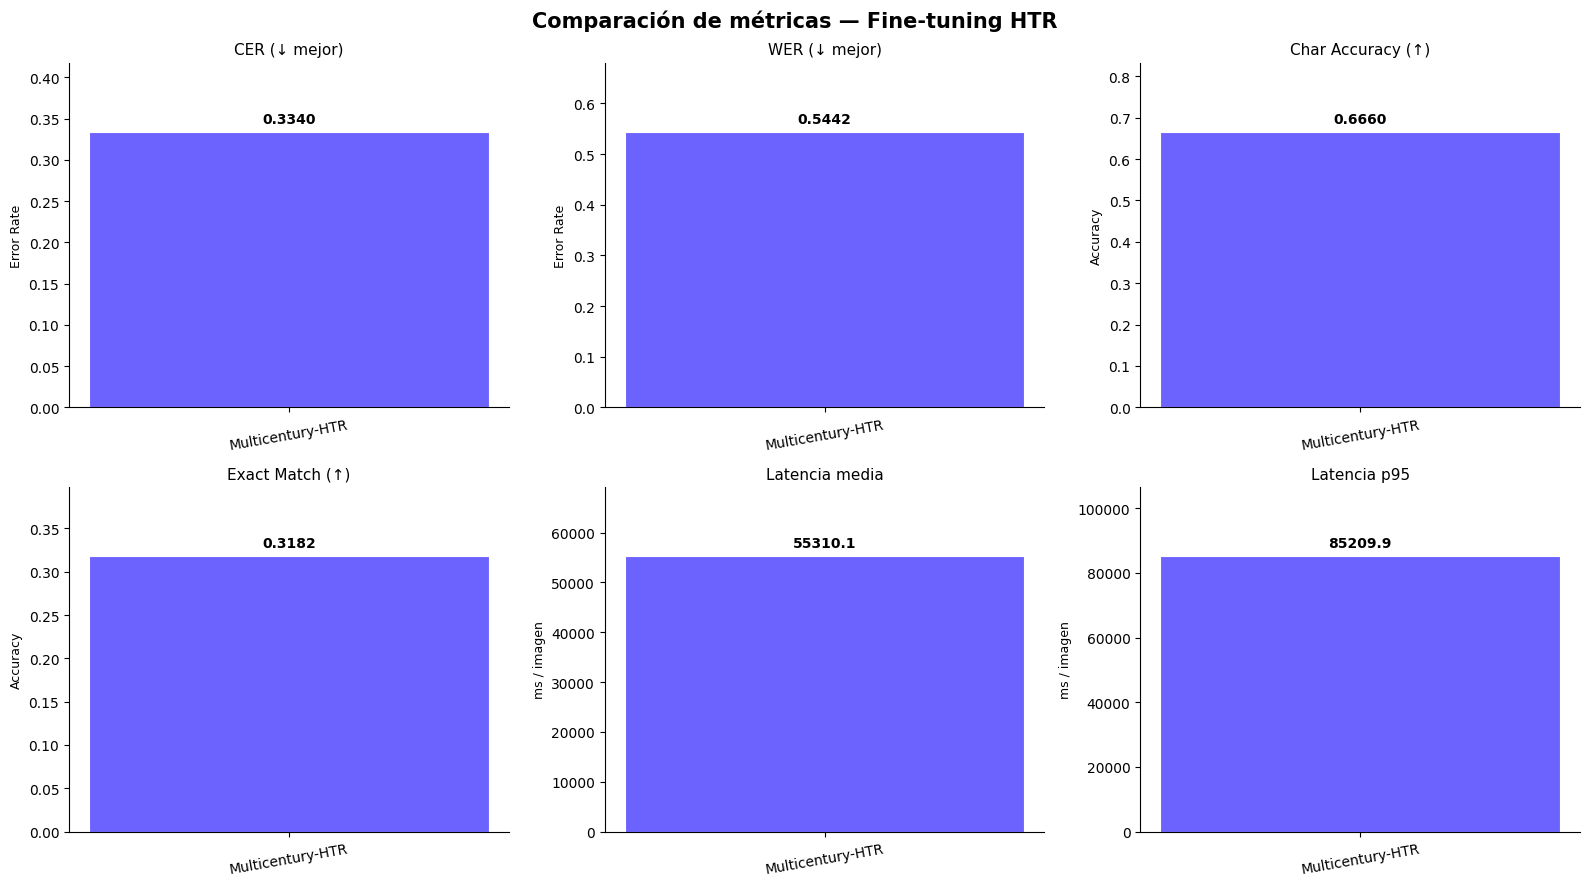

Gráfica guardada en: ..\..\models_weights\comparison_metrics.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Comparación de métricas — Fine-tuning HTR", fontsize=15, fontweight="bold")

models = results_df.index.tolist()
colors = ["#6C63FF", "#FF6B6B"] 

metric_groups = [
    ("cer",              "CER (↓ mejor)",    "Error Rate"),
    ("wer",              "WER (↓ mejor)",    "Error Rate"),
    ("char_acc",         "Char Accuracy (↑)","Accuracy"),
    ("exact_match",      "Exact Match (↑)",  "Accuracy"),
    ("latency_mean_ms",  "Latencia media",   "ms / imagen"),
    ("latency_p95_ms",   "Latencia p95",     "ms / imagen"),
]

for ax, (metric, title, ylabel) in zip(axes.flat, metric_groups):
    vals = [results_df.loc[m, metric] for m in models]
    bars = ax.bar(models, vals, color=colors, width=0.5, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                f"{v:.4f}" if v < 1 else f"{v:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.tick_params(axis="x", labelrotation=10)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada en:", OUTPUT_DIR / "comparison_metrics.png")

10. Tabla resumen exportada

In [15]:
summary = results_df[[
    "cer", "wer", "char_acc", "exact_match",
    "latency_mean_ms", "latency_p95_ms", 
    "n_samples",
]].copy()

summary.columns = [
    "CER ↓", "WER ↓", "Char Acc ↑", "Exact Match ↑",
    "Lat. Media (ms)", "Lat. p95 (ms)", 
    "Muestras",
]

print("=" * 70)
print("RESUMEN FINAL")
print("=" * 70)
print(summary.T.to_string())

winner = summary["CER ↓"].idxmin()
print(f"\nModelo con menor CER: {winner}")

csv_path = OUTPUT_DIR / "comparison_results.csv"
summary.to_csv(csv_path)
print(f"CSV guardado en: {csv_path}")

RESUMEN FINAL
model            Multicentury-HTR
CER ↓                      0.3340
WER ↓                      0.5442
Char Acc ↑                 0.6660
Exact Match ↑              0.3182
Lat. Media (ms)        55310.1400
Lat. p95 (ms)          85209.8800
Muestras                  44.0000

Modelo con menor CER: Multicentury-HTR
CSV guardado en: ..\..\models_weights\comparison_results.csv


11. Análisis cualitativo (muestras de error)

In [16]:
def qualitative_analysis(model_path, processor, records, model_name, n=5):
    # Cargamos modelo localmente dentro de la función para no saturar memoria
    model = VisionEncoderDecoderModel.from_pretrained(model_path).eval().to(DEVICE)
    errors = []
    
    for rec in records:
        img_path = CROPS_DIR / Path(rec["img_path"]).name
        image = Image.open(img_path).convert("RGB")
        label = rec["label"].strip()

        pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(DEVICE)
        with torch.no_grad():
            ids = model.generate(pixel_values, max_new_tokens=MAX_TARGET_LEN)
        pred = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()

        if pred != label:
            errors.append({"etiqueta": rec["etiqueta"], "label": label, "pred": pred})
        if len(errors) >= n: break

    print(f"\n--- Errores {model_name} ---")
    for e in errors:
        print(f"[{e['etiqueta']}] Esperado: '{e['label']}' | Predicho: '{e['pred']}'")
    
    del model
    torch.cuda.empty_cache()

qualitative_analysis(str(MULTI_OUT), multi_processor, test_recs, "Multicentury-HTR")

Loading weights:   0%|          | 0/636 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface


--- Errores Multicentury-HTR ---
[carroza_flores] Esperado: 'PARA SEPELIO' | Predicho: 'ESS SEPELO'
[n_contrato] Esperado: '000314' | Predicho: '000319'
[dni_contratante] Esperado: '17939375' | Predicho: '1733375'
[tel_contratante] Esperado: '941698863' | Predicho: '94169865'
[tel_contratante] Esperado: '941849652' | Predicho: '94184965'
